In [1]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import pandas as pd
import pickle

In [2]:
# Use GPU if available, otherwise use CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [3]:
# Loading Data
train_dataset = datasets.FashionMNIST(root = './data', train = True, download = True, transform = transforms.ToTensor())
test_dataset = datasets.FashionMNIST(root = './data', train = False, download = True, transform = transforms.ToTensor())

In [4]:
# SPLIT FOR REQUIREMENT: Cut the 60,000 training images into 50,000 for training and 10,000 for validation
train_dataset, val_dataset = torch.utils.data.random_split(train_dataset, [50000, 10000])

In [5]:
# DataLoaders serve the images in small groups of 100
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size = 100, shuffle = True)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size = 100)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size = 100)

In [6]:
# Neural Network
class NeuralModel(nn.Module):
    def __init__(self):
        super().__init__()
        
        # Top Layer
        self.flatten = nn.Flatten() # makes 28x28 to 784
        self.input_layer = nn.Linear(784, 16) #last output was 784, now output is 16
        self.relu = nn.ReLU() #apply activation function
        
        # Left Layers
        self.left_1 = nn.Linear(16, 8)
        self.left_2 = nn.Linear(8, 8)
        
        # Right Layers
        self.right_1 = nn.Linear(16, 12)
        self.right_2 = nn.Linear(12, 8)
        
        # Bottom Layer, Conacactenated 8 + 8 = 16
        self.output_layer = nn.Linear(16, 10)

    def forward(self, x):
        # Top Layer
        x = self.flatten(x)
        x = self.input_layer(x)
        x = self.relu(x)
        
        # Left Layer
        left_path = self.left_1(x)
        left_path = self.relu(left_path)
        
        # Left Layer Jump Connection
        jump = left_path #We saved this here in jump
        left_path = self.left_2(left_path)
        left_path = self.relu(left_path)
        left_path = left_path + jump #now old one added here again
        
        # Right Layer
        right_path = self.right_1(x)
        right_path = self.relu(right_path)
        right_path = self.right_2(right_path)
        right_path = self.relu(right_path)
        
        # Joining Layers
        merged = torch.cat((left_path, right_path), dim=1)
        
        # Final Layer
        logits = self.output_layer(merged)
        return logits

In [7]:
# Defining Model & Loss
model = NeuralModel().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

In [8]:
# Training Loop
train_losses = [] #List to save data
val_losses = []

In [9]:
for epoch in range(5):
    # Training Data
    model.train()
    total_train_loss = 0
    
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)
        
        optimizer.zero_grad() 
        loss.backward()       
        optimizer.step()      
        
        total_train_loss += loss.item()
        
    avg_train_loss = total_train_loss / len(train_loader)
    train_losses.append(avg_train_loss) #For every epoch
    
    # Validation Data
    model.eval()
    total_val_loss = 0
    
    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)
            total_val_loss += loss.item()
            
    avg_val_loss = total_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)
    
    print(f"Epoch {epoch + 1} -> Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

Epoch 1 -> Train Loss: 0.6001 | Val Loss: 0.4618
Epoch 2 -> Train Loss: 0.4394 | Val Loss: 0.5070
Epoch 3 -> Train Loss: 0.4147 | Val Loss: 0.4450
Epoch 4 -> Train Loss: 0.4015 | Val Loss: 0.4363
Epoch 5 -> Train Loss: 0.3892 | Val Loss: 0.4201


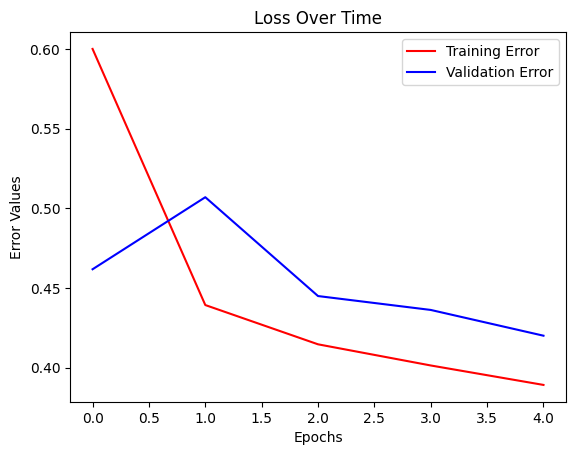

In [10]:
# Plot
plt.plot(train_losses, label="Training Error", color="red")
plt.plot(val_losses, label="Validation Error", color="blue")
plt.title("Loss Over Time")
plt.xlabel("Epochs")
plt.ylabel("Error Values")
plt.legend()
plt.savefig("loss_plot.png")  # Save image
plt.show()

In [11]:
# Saving Weights using pickle
weights_dict = model.state_dict()
with open("model_weights.pkl", "wb") as file:
    pickle.dump(weights_dict, file)
print("Saved weights to model_weights.pkl using Pickle!")

Saved weights to model_weights.pkl using Pickle!


In [12]:
# CSV File
final_predictions = []

In [13]:
# Testing
model.eval()

NeuralModel(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (input_layer): Linear(in_features=784, out_features=16, bias=True)
  (relu): ReLU()
  (left_1): Linear(in_features=16, out_features=8, bias=True)
  (left_2): Linear(in_features=8, out_features=8, bias=True)
  (right_1): Linear(in_features=16, out_features=12, bias=True)
  (right_2): Linear(in_features=12, out_features=8, bias=True)
  (output_layer): Linear(in_features=16, out_features=10, bias=True)
)

In [14]:
correct = 0
total = 0

In [15]:
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted_classes = torch.max(outputs, dim=1) #Picks Neuron with highest output
        total += labels.size(0)
        correct += (predicted_classes == labels).sum().item()
        final_predictions.extend(predicted_classes.cpu().numpy()) #Makes Numpy list of final prediction and keeps updating it
accuracy = 100 * correct / total
print(f'Accuracy = {accuracy:.2f}%')

Accuracy = 85.00%


In [16]:
df = pd.DataFrame({"Label": final_predictions})
df.to_csv("submission.csv", index=True, index_label="Index")
print("Saved final submission.csv data table!")

Saved final submission.csv data table!
